In [40]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for better color palettes

data_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/'

In [42]:
# Read CSV file into a DataFrame
df = pd.read_csv(data_path + 'S_seaice_extent_daily_v3.0_2.csv'
                ,  sep=';')

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']].astype(str).agg('-'.join, axis=1))
df.set_index('Date', inplace=True)
ds = xr.Dataset({'Extent': df['Extent']})

ds['day_of_year'] = ds['Date'].dt.dayofyear
ds['Year'] = ds['Date'].dt.year
ds = ds.set_coords('day_of_year')
ds = ds.set_coords('Year')
ds

<xarray.Dataset>
Dimensions:      (Date: 14919)
Coordinates:
  * Date         (Date) datetime64[ns] 1978-10-26 1978-10-28 ... 2024-03-07
    day_of_year  (Date) int64 299 301 303 305 307 309 311 ... 62 63 64 65 66 67
    Year         (Date) int64 1978 1978 1978 1978 1978 ... 2024 2024 2024 2024
Data variables:
    Extent       (Date) float64 17.62 17.8 17.67 17.53 ... 2.681 2.753 2.809

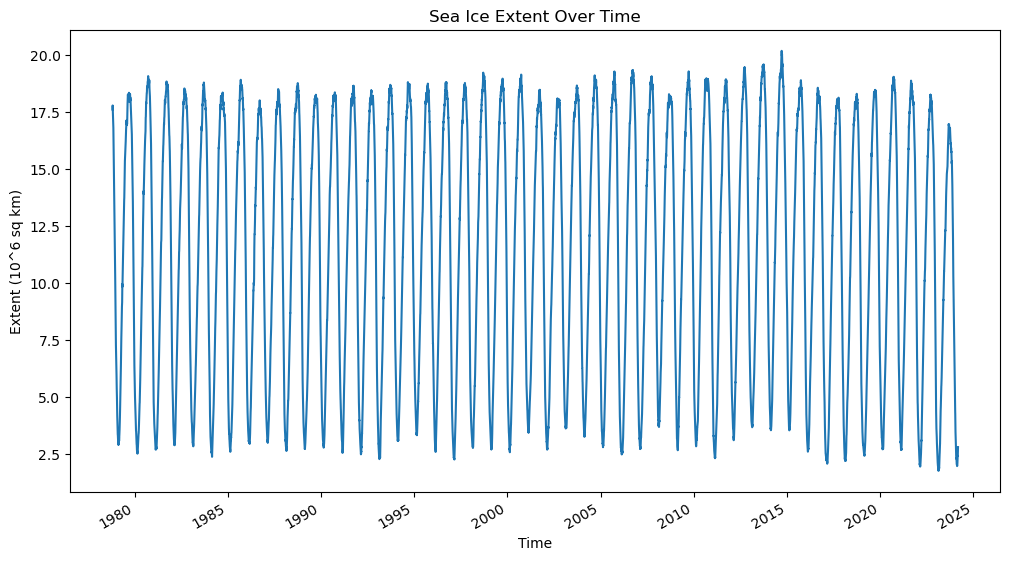

In [51]:
# Plot Extent over time
plt.figure(figsize=(12, 6))
ds['Extent'].plot()
plt.title('Sea Ice Extent Over Time')
plt.xlabel('Time')
plt.ylabel('Extent (10^6 sq km)')
plt.show()

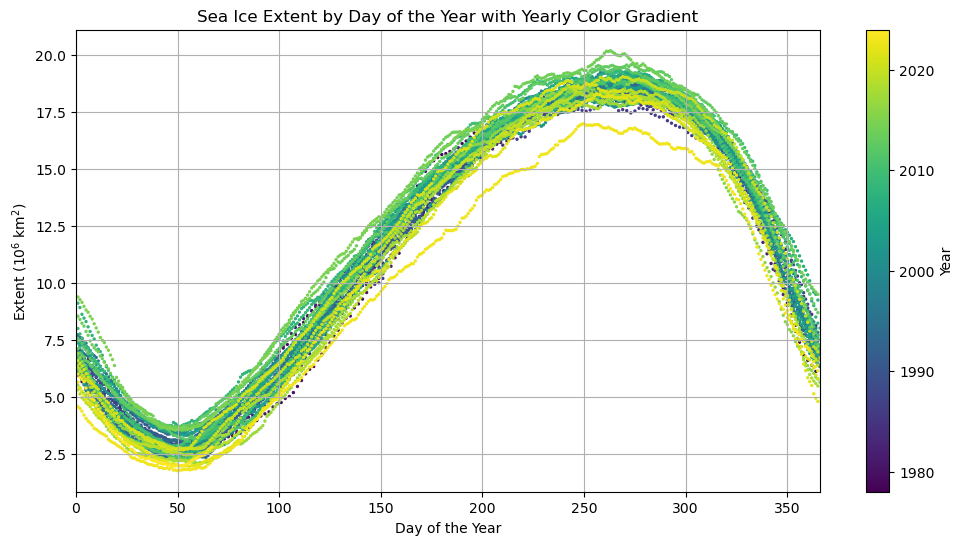

In [52]:
# Assuming you have a sequential color palette from seaborn
# You can choose other palettes or create your own
cmap = sns.color_palette("viridis", as_cmap=True)

# Plot Extent in terms of day of the year with color gradient by year
plt.figure(figsize=(12, 6))
sc = plt.scatter(ds['day_of_year'], ds['Extent'], c=ds['Year'], cmap=cmap, s=2)
plt.colorbar(sc, label='Year')
plt.grid()
plt.xlim([0, 366])
plt.title('Sea Ice Extent by Day of the Year with Yearly Color Gradient')
plt.xlabel('Day of the Year')
plt.ylabel('Extent ($10^6$ km$^2$)')
plt.savefig('Fig_SIE_with_colorbar.png')
plt.show()
